In [39]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.4904351e-05)  # constant metallicity (Z=0.02)
zmet = 1


ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

sp = fsps.StellarPopulation(zcontinuous=0, zmet = 1, sfh=3, add_neb_emission=False, add_neb_continuum=False)
Z = sp.zlegend[zmet - 1]
print(Z)

4.490434306654496e-05


In [40]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal))
wave, spec_fsps_nebfree = sp.get_spectrum(tage=13.8) 

In [41]:

sp.params['add_neb_emission'] = True
sp.params['add_neb_continuum'] = True
wave, spec_fsps_neb = sp.get_spectrum(tage=13.8)   

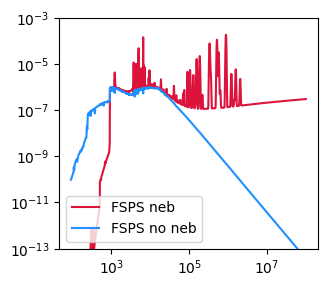

In [43]:
plt.figure(figsize = (10/3, 3))
plt.plot(wave, spec_fsps_neb, color = 'crimson', label = 'FSPS neb')
plt.plot(wave, spec_fsps_nebfree, color = 'dodgerblue', label = 'FSPS no neb')
plt.ylim(1e-13, 1e-3)
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [257]:
from pathlib import Path
import jax.numpy as jnp

class NebularModel:
    def __init__(self, cloudy_dust, sps_home, csp_lambda,
                 smooth_velocity=True, isoc_type = 'mist', nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=0.0):
        """
        Initializes a nebular emission model for use with stellar population synthesis output.

        Parameters
        ----------
        isoc_type : str
            Isochrone type (e.g., 'mist', 'pdva', 'bpss') used to identify the correct nebular files.
        cloudy_dust : bool
            If True, uses nebular models with dust attenuation from CLOUDY.
        sps_home : str or Path
            Path to the FSPS root directory containing the nebular subdirectory.
        csp_lambda : array-like
            Wavelength grid of the composite stellar population (CSP) spectrum [in Angstrom].

        smooth_velocity : bool, optional
            If True, smoothing is velocity-based (km/s). If False, use fixed smoothing in Å.
        nebnz : int, optional
            Number of metallicity grid points.
        nebnage : int, optional
            Number of age grid points.
        nebnip : int, optional
            Number of ionization parameter grid points.
        nebular_smooth_init : float, optional
            Initial smoothing width in km/s or Å (depending on `smooth_velocity`).
        """

        # Store CSP wavelength grid and spectrum length
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size

        # Store constants and hyperparameters
        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # Set filenames for nebular continuum and line emission based on isochrone type and dusty flag
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')   # Nebular continuum file
        self.line_file = base.with_suffix('.lines')  # Nebular emission line file

        # Load the nebular continuum cube and grids
        self._load_continuum()

        # Load the nebular emission line cube and line positions
        self._load_lines()

        # Compute the minimum spectral resolution for each line (in Å)
        self._compute_resolution_elements()

        # Build Gaussian line profiles for all emission lines on the CSP wavelength grid
        self._build_gaussians()
    
    def _load_continuum(self): 
        # Open the nebular continuum file and skip the header
        with open(self.cont_file, 'r') as f:
            f.readline()  # skip header line

            # Read the wavelength grid of the nebular continuum model
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)
            self.readlambneb = jnp.asarray(readlambneb)

            # Read the rest of the file content into memory
            lines = f.readlines()

            # Allocate arrays for interpolated continuum and parameter grids
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)   # gas metallicity
            logu_grid = np.zeros(self.nebnip)  # ionization parameter
            age_grid = np.zeros(self.nebnage)  # age in yr

            idx = 0  # line index in the file
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        # First line gives (logZ, age, logU) for this cube slice
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1

                        # Second line gives the continuum spectrum (Lsun/Hz/Q)
                        cont = np.array([float(x) for x in lines[idx].split()])
                        logcont = np.log10(cont + 10**-95)  # avoid log(0)
                        # Interpolate onto CSP wavelength grid
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

        # Store as JAX arrays for GPU compatibility
        self.nebem_cont = jnp.asarray(cont_cube)
        self.nebem_logz = jnp.asarray(logz_grid)
        self.nebem_logu = jnp.asarray(logu_grid)
        self.nebem_age = jnp.log10(jnp.asarray(age_grid))  # log10(age/yr)
    
    def _load_lines(self):
        # Open the nebular emission line file
        with open(self.line_file, 'r') as f:
            f.readline()  # Skip header line

            # Read the rest-frame line center wavelengths (in Å)
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]

            # Allocate array to store log10(line luminosities) in Lsun/Q
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            # Loop over metallicity, age, and ionization parameter grid
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()  # metadata line (logZ, age, logU), already known
                        linevals = np.array([float(x) for x in f.readline().split()])
                        # Store log10(L/Q), avoiding log(0)
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            # Store line emission cube as a JAX array for GPU use
            self.nebem_line = jnp.asarray(line_cube)

    def _compute_resolution_elements(self):
        '''Avoid delta function spikes in nebular lines when the broadening of the gaussian is smaller than the resolution element.'''
        # For each emission line, find the nearest wavelength index just below the line center
        idx = jnp.clip(
            jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1,
            1, self.nspec - 2 
        )
        
        # Estimate the local spectral resolution element Δλ around each line
        dlam_pre = self.csp_lambda[idx + 1] - self.csp_lambda[idx]
        dlam = dlam_pre*2/2.355
        neb_res_min = jnp.maximum(dlam, self.neb_res_min*self.csp_lambda[idx]/const.c * 1e13)#sigma of the line angs
        # Store the minimum resolution per line as a JAX array
        self.neb_res_min = jnp.asarray(neb_res_min)

    def _compute_resolution_elements(self):
        '''Avoid delta function spikes in nebular lines when the broadening of the gaussian is smaller than the resolution element.'''
        # For each emission line, find the nearest wavelength index just below the line center
        idx = jnp.clip(jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1, 1, self.nspec - 2)
        self.neb_res_min = self.csp_lambda[idx + 1] - self.csp_lambda[idx]

    def _build_gaussians(self):
        """
        Precompute normalized Gaussian line profiles for each emission line,
        on the given wavelength grid. These profiles model the line broadening
        (either in velocity space or wavelength space), and are stored for
        later use when adding line emission to the SED.
        """

        def compute_line(i):
            lam0 = self.nebem_line_pos[i]
            dlam = jnp.where(
                self.smooth_velocity,
                lam0 * self.nebular_smooth_init / (const.c *10**10)* 1e13,  # in Angstrom
                self.nebular_smooth_init
            )
            dlam = jnp.maximum(dlam, self.neb_res_min[i] * 2.0)

            norm = 1.0 / (jnp.sqrt(2 * jnp.pi) * dlam)
            profile = jnp.exp(-0.5 * ((self.csp_lambda - lam0) / dlam) ** 2)
            scaling = lam0 ** 2 / (const.c * 10**10)

            return norm * profile * scaling  # shape: (n_lambda,)

        # Vectorize over all emission lines
        self.gaussnebarr = jnp.stack([compute_line(i) for i in range(self.nebem_line_pos.shape[0])], axis=1)
        return self.gaussnebarr  # shape: (n_lambda, n_lines)

    def get_default_params(self):
        """
        Return a NamedTuple of default nebular fit parameters.

        Defaults match FSPS: gas_logz=0.0 (solar), gas_logu=-2.0 (moderate ionization).
        """
        from typing import NamedTuple, Any

        defaults = {
            'gas_logz': 0.0,
            'gas_logu': -2.0,
        }

        NebParams = NamedTuple("NebParams", [(k, Any) for k in defaults.keys()])
        return NebParams(**defaults)

    def get_param_names(self):
        """Return a list of fittable nebular parameter names."""
        return ['gas_logz', 'gas_logu']

    def evaluate_logQ(self, logZ, logU, logage, logQ):

        # Locate and compute fractional offsets in grid
        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)

        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)

        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)
        
        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear_interp(self.nebem_line, z1, dz, a1, da, u1, du)

        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed

        return (cont_flux, line_spec)

    def evaluate_ssp(self, logZ, logU, logage, ssp_flux, wave):

        # Locate and compute fractional offsets in grid
        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)

        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)

        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)
        
        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear_interp(self.nebem_line, z1, dz, a1, da, u1, du)

        LL = 912.0  # Å

        mask = wave < LL                                  # (n_wave,)
        ssp_wave_ion  = wave[mask]                        # (n_ion,)
        ssp_flux_ion  = ssp_flux[..., mask]                   # (..., n_ion)
        qq = jnp.trapezoid(ssp_flux_ion/ssp_wave_ion, x=ssp_wave_ion)  # [L_sun Å / Å]
    
        # Convert to photons/s units: [L_sun] / [h] = [erg s^-1] / [erg s] = [s^-1]
        logQ = jnp.log10(qq / const.h) + jnp.log10(const.L_sun)


        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed

        return (cont_flux, line_spec)


def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)   

def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])

    # Stack the 8 corners along a new axis (0), each of shape (nspec,)
    slices = jnp.stack([
        cube[:, z1,   a1,   u1],
        cube[:, z1,   a1,   u1+1],
        cube[:, z1,   a1+1, u1],
        cube[:, z1,   a1+1, u1+1],
        cube[:, z1+1, a1,   u1],
        cube[:, z1+1, a1,   u1+1],
        cube[:, z1+1, a1+1, u1],
        cube[:, z1+1, a1+1, u1+1]
    ], axis=0)  # shape (8, nspec)

    # Weighted sum over the 8 corners
    return jnp.sum(w[:, None] * slices, axis=0)  # shape (nspec,)






In [258]:
sp.params['gas_logu']

-2

In [ ]:

import jax.numpy as jnp  # JAX's numpy-compatible array operations
from jax import jit, vmap      # Just-in-time compilation decorator for performance
from ceridwen.dust import Dust, DiffuseDust  # Import Dust model for handling dust attenuation
from ceridwen.dust import DustEmission
#from ceridwen.neb import NebularModel
import jax.numpy as jnp
from jax import vmap
from jax.scipy.special import logsumexp

LN10 = jnp.log10(10.)

from typing import NamedTuple, Any
import pprint

import astropy.constants as const

tiny_number = 1e-70


def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * (fnu / (lam**2))

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    """
    Compute the integrated star formation weight for CSP modeling.
    
    This function calculates the contribution of stellar populations formed within 
    specific age bins to the overall CSP spectrum. It handles the integration of
    the star formation rate over time intervals, accounting for linear interpolation
    between adjacent time points.
    
    The integration accounts for:
    - Linear interpolation of SFR between time bins (sf_slope term)
    - Proper weighting by formation time and current age
    - Log-linear time scaling typical in stellar population models
    
    Args:
        tlimhi: Upper integration limit in log(age) (younger ages)
        tlimlo: Lower integration limit in log(age) (older ages) 
        a_broadcasted: Linear term coefficient for SFH interpolation
        sf_slope_broadcasted: Slope term for linear SFH interpolation
        logage_broadcasted: Log age of SSP bin being weighted
        
    Returns:
        intsfwght: Integrated star formation weight for the age interval
    """
    # Natural log conversion factor (log10(e)) for mathematical convenience
    loge = jnp.log10(jnp.e)

    # Convert log ages back to linear scale for integration calculations
    exp_tlimlo = 10**tlimlo  # Shape: (i, j) - Linear age at lower limit (older)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j) - Linear age at upper limit (younger)  
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j) - Squared for quadratic terms
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j) - Squared for quadratic terms

    # Compute star formation weight at lower integration limit (older ages)
    # b1: Linear term contribution at older boundary
    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    # c1: Quadratic term contribution from SFH slope at older boundary  
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1  # Total weight contribution at older boundary

    # Compute star formation weight at upper integration limit (younger ages)
    # b2: Linear term contribution at younger boundary
    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    # c2: Quadratic term contribution from SFH slope at younger boundary
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2  # Total weight contribution at younger boundary

    # Fundamental theorem of calculus: integrated weight = upper_limit - lower_limit
    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght

class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, theta_dict = {'lookback_time': 13.8 - jnp.linspace(1e-2, 13.8, 100)}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = True, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 'laws': ['powerlaw']},
                 diffuse_law = 'kriek_conroy', verbose = True, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            tuniv: Age of the universe in Gyr (default: 13.8 Gyr)
            tiny_logt: Minimum lookback time in log(years) to prevent numerical issues
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        # Extract and convert SSP data to JAX arrays for efficient computation
        self.flux = jnp.array(SSPData.ssp_flux)        # SSP flux array: shape (n_metallicity, n_age, n_wavelength)
        self.wave = jnp.array(SSPData.ssp_wave)        # Wavelength grid in Angstroms: shape (n_wavelength,)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)  # SSP ages in log10(Gyr): shape (n_age,)
        self.zmet = jnp.array(SSPData.ssp_lgmet)       # SSP metallicities in log10(Z/Zsun): shape (n_metallicity,)
        self.logqq = jnp.array(SSPData.log_qq)         # SSP log10(Q/Qsun): shape (n_age, n_metallicity)

        # Convert log metallicities to linear scale for interpolation calculations
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)  # Linear metallicity scale: shape (n_metallicity,)

        # Convert SSP age grid from log(Gyr) to log(yr) for internal time calculations
        # This standardizes time units throughout the CSP calculations
        self.ssp_ages_lgyr = self.ages + 9  # Convert from log(Gyr) to log(yr): log10(Gyr) + log10(1e9) = log10(yr)
        
        # Universe age and numerical precision parameters
        self.tuniv = tuniv        # Age of the Universe in Gyr (cosmological parameter)
        self.tiny_logt = tiny_logt  # Smallest lookback time we accept in log(years) to prevent numerical issues

        self.sps_home = sps_home  # Path to FSPS home directory for stellar population synthesis



        if add_diffuse_dust or add_dust:
            self.set_attenuation_function(add_diffuse_dust, add_dust)

        theta_dict = self.initialize_dust_components(
                                                    add_dust,
                                                    add_diffuse_dust,
                                                    add_dust_emission,
                                                    theta_dict,
                                                    init_dust_params,
                                                    diffuse_law,
                                                    sps_home)
                                                    
        theta_dict = self.initialize_neb(add_neb, theta_dict, init_neb_params, sps_home)

        self.configure_spectrum_model(add_dust, add_diffuse_dust, add_dust_emission, add_neb, sps_home)
    
        # SSP weight calculation method depending on metallicity history    
        if zh_const:
            self.calculate_ssp_weights = self.calculate_ssp_weights_const_zh    
        else:
            self.calculate_ssp_weights = self.calculate_ssp_weights_var_zh

        # Determine Model Structure
        self.summary = self.initialize_model_structure(theta_dict)
        if verbose:
            pprint.pprint(self.summary.keys())

        self.params = self.build_params_from_summary(self.summary)

    def build_params_from_summary(self, summary):
        """Create a self.params-style summary dictionary from a summary dict."""
        params = {}

        for key, val in summary.items():
            if not key.endswith('_idx'):
                continue

            # parameter base name, e.g. "sfh_idx" → "sfh"
            pname = key[:-4]
            idx = summary[key]

            if len(idx) == 1:
                params[pname] = {'pos': f"{idx[0]}", 'length': 1}
            elif len(idx) <= 3:
                params[pname] = {'pos': str(idx), 'length': len(idx)}
            else:
                params[pname] = {'pos': f"{idx[0]}–{idx[-1]}", 'length': len(idx)}

        return params
        
    @property
    def all_params(self):
        ordered = sorted(
            self.params.items(),
            key=lambda item: int(item[1]["pos"])
        )

        return {
            name: self.theta_init[int(info["pos"])]
            for name, info in ordered
        }
    def set_attenuation_function(self, add_diffuse_dust, add_dust):
        """
        Define and assign the appropriate dust attenuation function based on model configuration.
        """

        # --- Case 1: both binwise and diffuse dust are included ---
        if add_diffuse_dust and add_dust: 
            
            def attenuate(wave, theta):
                # binwise
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)

                # diffuse
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                return attn, attn_diffuse
            print("Using combined (binwise + diffuse) dust attenuation.")
            self.attenuate_dust = attenuate

        elif add_dust and not add_diffuse_dust:

            def attenuate_without_diffuse(wave, theta):
                # --- Extract bin-based dust parameters
                dust_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.dust_param_names)
                dust_params = self.DustParams(*dust_param_values)
                attn = self.dust_attn.compute_attenuation(wave, dust_params)  # shape (num_bins, len(wave))

                # --- Dummy diffuse attenuation: shape (1, len(wave)), all ones
                attn_diffuse = jnp.zeros((1, wave.shape[0]))

                return attn, attn_diffuse

            print("Using only binwise dust attenuation.")
            self.attenuate_dust = attenuate_without_diffuse

        elif add_diffuse_dust and not add_dust:

            self.bin_low = jnp.array([-jnp.inf])
            self.bin_high = jnp.array([jnp.inf])

            def attenuate_diffuse_only(wave, theta):
                # --- Extract diffuse dust parameters
                diffuse_param_values = tuple(theta[getattr(self, f"{name}_idx")] for name in self.diff_param_names)
                diffuse_params = self.DiffDustParams(*diffuse_param_values)
                attn_diffuse = self.diff_dust.compute_attenuation(wave, diffuse_params)

                # --- Dummy binwise attenuation: shape (1, len(wave)), all ones
                attn = jnp.zeros((1, wave.shape[0]))

                return attn, attn_diffuse

            print("Using only diffuse dust attenuation.")
            self.attenuate_dust = attenuate_diffuse_only

    def initialize_neb(self, add_neb: bool, theta_dict: dict, init_neb_params: dict, sps_home: str) -> dict:
        """
        Initialize dust-related models and register their parameters.
        """
        if add_neb:
            init_neb_params.update({'sps_home': sps_home, 'csp_lambda': self.wave})
            print("Initializing Nebular Emission model...")
            self.neb = NebularModel(**init_neb_params)

            neb_fit_dict = self.neb.get_default_params()._asdict()
            for k, v in neb_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.neb_param_names = list(neb_fit_dict.keys())
            self.NebParams = NamedTuple(
                "NebParams", [(name, float) for name in self.neb_param_names]
            )

            self.young_mask = self.ages < jnp.log10(22.0 * 1e-3)     # (n_age,)
            self.young_idx  = jnp.where(self.young_mask, size=self.young_mask.size, fill_value=0)[0]
            self.n_young    = jnp.sum(self.young_mask)

            self.idx_ion = int(jnp.searchsorted(self.wave, 912.0))

        return theta_dict

            
    def initialize_dust_components(self, add_dust: bool, add_diffuse_dust: bool, add_dust_emission: bool,
                                    theta_dict: dict, init_dust_params: dict, diffuse_law: str, sps_home: str) -> dict:
        """
        Initialize dust-related models and register their parameters.
        """
        if add_dust:
            print("Initializing Dust attenuation model...")
            self.dust_attn = Dust(**init_dust_params)

            self.bin_low = jnp.array([edge[0] for edge in self.dust_attn.bin_edges])
            self.bin_high = jnp.array([edge[1] for edge in self.dust_attn.bin_edges])

            dust_fit_dict = self.dust_attn.get_default_fit_params()._asdict()
            for k, v in dust_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.dust_param_names = list(dust_fit_dict.keys())
            self.DustParams = NamedTuple(
                "DustParams", [(name, float) for name in self.dust_param_names]
            )

        if add_diffuse_dust:
            print("Initializing DiffuseDust model...")
            self.diff_dust = DiffuseDust(diffuse_law)

            diff_fit_dict = self.diff_dust.get_default_params()._asdict()
            for k, v in diff_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.diff_param_names = list(diff_fit_dict.keys())
            self.DiffDustParams = NamedTuple(
                "DiffDustParams", [(name, float) for name in self.diff_param_names]
            )

        if add_dust_emission:
            print("Initializing DustEmission model...")
            self.dust_emi = DustEmission(spec_lambda=self.wave, dust_file=sps_home)

            emi_fit_dict = self.dust_emi.get_default_params()._asdict()
            for k, v in emi_fit_dict.items():
                if k not in theta_dict:
                    theta_dict[k] = v

            self.emi_param_names = list(emi_fit_dict.keys())
            self.DustEmiParams = NamedTuple(
                "DustEmiParams", [(name, float) for name in self.emi_param_names]
            )

        print("Dust initialization complete.")
        return theta_dict

    def configure_spectrum_model(self, add_dust, add_diffuse_dust, add_dust_emission, add_neb, sps_home):
        """
        Configure which get_spectrum method to use depending on dust and nebular settings.
        """
        if add_dust or add_diffuse_dust:
            part1 = 'dust_'
            message1 = 'Get spectrum with dust attenuation'
        else:
            part1 = 'nodust_'
            message1 = 'Get spectrum without dust attenuation'
        if add_neb:
            part2 = 'neb_'
            message2 = ', with nebular continuum and lines'
        else:
            part2 = 'noneb_'
            message2 = ', without nebular contribution'
        if add_dust_emission:
            if not add_dust or not add_diffuse_dust:
                raise ValueError(
                    "Dust emission requires both dust attenuation and diffuse dust to be enabled."
                )
            part3 = 'dustemi'
            message3 = ', and with dust emission.'
        else:
            part3 = 'nodustemi'
            message3 = ', and without dust emission.'
        message = message1 + message2 + message3
        key = part1 + part2 + part3
        mapping  = {
                'dust_neb_dustemi':  self.get_spectrum_dattn_dem_neb,
                'dust_neb_nodustemi': self.get_spectrum_dattn_nodem_neb,
                'dust_noneb_dustemi': self.get_spectrum_dattn_dem_noneb,
                'dust_noneb_nodustemi':  self.get_spectrum_dattn_nodem_noneb,
                'nodust_neb_nodustemi':  self.get_spectrum_nodattn_nodem_neb,
                'nodust_noneb_nodustemi':  self.get_spectrum_nodattn_nodem_noneb
            }
        print(message)
        self.get_spectrum = mapping[key]


    def initialize_model_structure(self, theta_dict: dict):
        """
        Initializes model structure from a flexible theta_dict.

        Required:
            - 'sfh': jnp.ndarray of shape (n_time,)
            - 'lookback_time': jnp.ndarray of shape (n_time,)

        Optional:
            - Any number of scalar or array parameters (e.g. 'Z', 'zh', 'dust', ...)
        """

        # --- Required base parameters
        self.sfh_times = theta_dict['lookback_time'] * 1e9  # Gyr → yr
        sfh = jnp.atleast_1d(theta_dict['sfh'])
        self.n_time = self.sfh_times.size

        assert sfh.shape == (self.n_time,), "'sfh' must match 'lookback_time' length"
        self.sfh_idx = jnp.arange(self.n_time)

        theta_parts = [sfh]
        current_idx = self.n_time  # start after sfh

        # Track special handling of Z vs. zh
        self.zh_is_scalar = None

        for key, val in theta_dict.items():
            if key in ('sfh', 'lookback_time'):
                continue  # already handled

            arr = jnp.atleast_1d(val)

            if key == 'zh':
                assert arr.shape == (self.n_time,), "'zh' must match 'lookback_time' length"
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + self.n_time))
                self.zh_is_scalar = False
                current_idx += self.n_time

            elif key == 'Z':
                assert arr.shape == (1,), "'Z' must be a scalar"
                setattr(self, f'{key}_idx', jnp.array([current_idx]))
                self.zh_is_scalar = True
                current_idx += 1

            else:
                # General case: scalar or vector parameters
                arr_shape = arr.shape
                flat_len = arr.size
                setattr(self, f'{key}_idx', jnp.arange(current_idx, current_idx + flat_len))
                current_idx += flat_len

            # Append to flat vector
            theta_parts.append(arr)

        # Final flat parameter vector
        self.theta_init = jnp.concatenate(theta_parts)
        
        summary = {
            'sfh_times': self.sfh_times.tolist(),
            'sfh': sfh.tolist(),
            'theta_init': self.theta_init.tolist(),
        }

        # Dynamically include all *_idx attributes
        for name in dir(self):
            if name.endswith('_idx') and not name.startswith('__'):
                summary[name] = getattr(self, name).tolist()

        return summary
   
    def predict(self, theta):
        spectrum = self.get_spectrum(theta = theta)
        return spectrum

    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object, including
        dust attenuation and dust emission models if present.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )

        repr_str += f"Model Params: {self.params}\n"

        # Spectrum status
        repr_str += "Spectrum: Computed\n" if hasattr(self, "spectrum") else "Spectrum: Not computed yet\n"

        # Dust attenuation (if present)
        if getattr(self, "dust", None) is not None:
            repr_str += f"Dust Model: {repr(self.dust)}\n"
            if hasattr(self, "bin_low") and hasattr(self, "bin_high"):
                repr_str += f"  Dust Bins: {len(self.bin_low)} (low={self.bin_low}, high={self.bin_high})\n"
        else:
            repr_str += "Dust Model: None\n"

        # Dust emission (if present)
        if getattr(self, "emi", None) is not None:
            repr_str += f"Dust Emission: {repr(self.emi)}\n"
        else:
            repr_str += "Dust Emission: None\n"

        return repr_str

 
    def get_spectrum_dattn_dem_neb(self):
        """
        Get the spectrum of the CSP with dust attenuation, dust emission, and nebular emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
  
    def get_spectrum_dattn_nodem_neb(self):
        """
        Get the spectrum of the CSP with dust attenuation and nebular emission, but no dust emission.
        """
        raise NotImplementedError("This method is not yet implemented.")
    
    def get_spectrum_dattn_nodem_noneb(self, theta):

        """
        Get the spectrum of the CSP with dust attenuation, but no dust emission or nebular emission.
        """

        attn, attn_diffuse = self.attenuate_dust(self.wave, theta)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)
        has_bin = jnp.any(is_in_bin, axis=1)

        atten_matrix = jnp.where(has_bin[:, None], jnp.exp(-attn[bin_indices]), jnp.ones_like(attn[0]))
        dusty_flux = self.flux * atten_matrix[None, :, :]
        weights = self.calculate_ssp_weights(theta)
        spectrum_dust = jnp.sum(weights[:, :, None] * dusty_flux, axis=(0, 1))

        # apply diffuse dust, diffuse dust is not included, this is just multiplying with ones
        attenuated = spectrum_dust * jnp.exp(-attn_diffuse)
        self.spectrum = jnp.reshape(attenuated, (-1,))
        return self.spectrum

    def get_spectrum_dattn_dem_noneb(self, theta):
        """
        Get the spectrum of the CSP with dust attenuation and dust emission, but no nebular emission.
        """
        attn, attn_diffuse = self.attenuate_dust(self.wave, theta)

        is_in_bin = (self.ages[:, None] >= self.bin_low[None, :]) & (self.ages[:, None] < self.bin_high[None, :])
        bin_indices = jnp.argmax(is_in_bin, axis=1)
        has_bin = jnp.any(is_in_bin, axis=1)

        # add age bin dust attenuation
        atten_matrix = jnp.where(has_bin[:, None], jnp.exp(-attn[bin_indices]), jnp.ones_like(attn[0]))
        dusty_flux = self.flux * atten_matrix[None, :, :]
        weights = self.calculate_ssp_weights(theta)

        spectrum_dust_free = jnp.sum(weights[:, :, None] * self.flux, axis=(0, 1))
        spectrum_dust = jnp.sum(weights[:, :, None] * dusty_flux, axis=(0, 1))

        # apply diffuse dust
        attenuated = spectrum_dust * jnp.exp(-attn_diffuse)
        self.spec_attn = attenuated
        
        dust_emi_spectrum, self.mdust, self.tduste = self.dust_emi.compute_dust_emission(spec_attn=self.spec_attn, spec_dustfree=spectrum_dust_free,
                                                                                spec_lambda=self.wave, diffuse_curve=jnp.exp(-attn_diffuse),
                                                                                duste_qpah=theta[self.duste_qpah_idx],
                                                                                duste_umin=theta[self.duste_umin_idx],
                                                                                duste_gamma=theta[self.duste_gamma_idx])
        self.spectrum = dust_emi_spectrum
        return self.spectrum

    def get_spectrum_nodattn_nodem_noneb(self, theta):
        
        """
        Compute CSP spectrum at fixed metallicity (no dust, no nebular).
        """
        
        total_weights = self.calculate_ssp_weights(theta=theta)
        
        self.spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        return self.spectrum
 
    def calculate_ssp_weights_const_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)
        total_sfh_weights = sfh_weights.sum(axis=0) # Shape: (n_time,)

        # Metallicity handling: constant metallicity case
        target_Z = theta[self.Z_idx] # scalar

        # 1. Find interpolation indices along z-axis
        z_idx = jnp.searchsorted(self.zmet, target_Z, side='left')
        z_idx = jnp.clip(z_idx, 1, len(self.zmet) - 1)

        z1 = self.zmet[z_idx - 1]
        z2 = self.zmet[z_idx]
        w = (target_Z - z1) / (z2 - z1)

        # 2. Prepare zeroed weights cube: (n_z, n_age)
        total_weights = jnp.zeros((len(self.zmet), len(self.ages)))  # (n_z, n_age)

        # 3. Add the weights to bins k and k+1 with linear interpolation
        total_weights = total_weights.at[z_idx - 1].add((1 - w) * total_sfh_weights)
        total_weights = total_weights.at[z_idx].add(w * total_sfh_weights)
        
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1

        return total_weights
    
    def calculate_ssp_weights_var_zh(self, theta):
        """
        Calculate SSP weights for CSP spectrum generation.
        
        This is the core method that computes how much each SSP (defined by age and metallicity)
        contributes to the final CSP spectrum based on the star formation and metallicity histories.
        
        The algorithm:
        1. Interpolates SFH linearly between time bins
        2. Computes mass formed in each time interval  
        3. Distributes this mass across SSP age bins via integration
        4. Handles metallicity evolution through linear interpolation
        
        Dimensions: i = number of SFH time bins (len(sfh) - 1), j = number of SSP ages (len(ssp_ages_lgyr) - 1)
        
        Returns:
            total_weights: Array of SSP weights, shape depends on metallicity history:
                         - No metallicity history: (1, n_age)
                         - With metallicity history: (n_metallicity, n_age)
        """
        
        # Ensure SFH values are positive to avoid numerical issues
        sfh = theta[self.sfh_idx]
        sfh = jnp.clip(sfh, 1e-30, None)  # Ensure SFH is non-negative - shape (i+1)

        # === TIME BINNING AND SFH INTERPOLATION SETUP ===
        # Define time intervals from the SFH grid
        t1 = self.sfh_times[1:] # Beginning of time intervals (older times) - shape: (i,)
        t2 = self.sfh_times[:-1] # End of time intervals (younger times) - shape: (i,)

        
        # Compute slope for linear interpolation of SFH between adjacent points
        # This allows smooth SFH evolution within each time bin rather than step functions
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (i,) - Normalized SFH slope

        # === TIME CLIPPING AND MASS CALCULATION ===
        # Clip times to physically valid range to avoid extrapolation beyond SSP grid
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1])  # Shape: (i,) - Clipped older times
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.ssp_ages_lgyr[-1]) # Shape: (i,) - Clipped younger times
        sf_trunc = tage - tq  # Shape: (i,) - Effective time interval after clipping


        # Calculate total stellar mass formed in each time interval
        # Accounts for linear SFH variation within the interval via trapezoidal rule
        m2 = (
                sfh[1:]  # SFR at younger edge of interval
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))  # Correction for linear SFH slope
                * sf_trunc  # Multiply by time interval duration
            )  # Shape: (i,) - Total stellar mass formed in each interval

        # Calculate parameters for linear SFH interpolation within integration
        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (i,) - Time offset for slope calculation
        a = 1 - sf_slope * tprime  # Shape: (i,) - Linear interpolation coefficient


        # SSP-related computations
        ssp_dt = jnp.diff(self.ssp_ages_lgyr)  # Time intervals in SSP (shape: (j,))
        logage_lft = self.ssp_ages_lgyr[1:]    # Left edge of log-age bins (shape: (j,))
        logage_rght = self.ssp_ages_lgyr[:-1]  # Right edge of log-age bins (shape: (j,))


        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (i, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (i, 1))


        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (i, j)


        # Mask computation
        j_indices = jnp.arange(len(self.ssp_ages_lgyr))  # Indices for SSP bins (shape: (j,))
        jmin = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t1)) - 1, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)
        jmax = jnp.clip(jnp.searchsorted(self.ssp_ages_lgyr, jnp.log10(t2)) + 2, 0, len(self.ssp_ages_lgyr) - 1)  # Shape: (i,)


        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (i, n_time)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (i, j))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (i, j))

    
        # Broadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # broadcast to (1, j)
        logage_rght_broadcasted = logage_rght[None, :]  # broadcast to (1, j)
 

        a_broadcasted = a[:, None]  # broadcast to (i, 1)
        sf_slope_broadcasted = sf_slope[:, None]  # broadcast to (i, 1)


        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted) # Shape: (i, j)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)


        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)  # Shape: (i, j)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)


        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  # Shape: (i, n_time)
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, n_time)

        m1 = jnp.sum(w1, axis=1) #shape (i,)
        
        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (i, n_time)


        zh = theta[self.zh_idx]  # Shape: (i,)
        zbin = (zh[:-1] + zh[1:]) / 2 # Shape: (i,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
        k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
                
        # Logarithmic bin size — protect against divide-by-zero
        logz_k     = self.zlegend[k]
        logz_k1    = self.zlegend[k + 1]
        bin_size   = jnp.maximum(logz_k1 - logz_k, tiny_number) # Shape: (i,)

        dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
        dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation
        total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages))) # Shape: (i, n_z, n_time)

        total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights) # Shape: (i, n_z, n_time)
        total_weights = total_weights.sum(axis=0) #/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)

        # See how much is going into each z bin:
        z_weights = jnp.sum(total_weights, axis=(1))  # shape (n_z,)
            
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights/ (self.n_time - 1)

    def get_spectrum_nodattn_nodem_nebold(self, theta):
        """
        Compute the CSP spectrum including nebular emission
        (only for SSPs younger than 10 Myr),
        with interpolation in metallicity.

        Additionally, for young SSPs (<10 Myr), all stellar flux
        shortward of 912 Å is set to zero because we assume
        all ionizing photons are absorbed into nebular emission.
        """
        total_weights = self.calculate_ssp_weights(theta=theta)  # (n_met, n_age)
        

        logZ_gas  = theta[self.gas_logz_idx]
        logU      = theta[self.gas_logu_idx]
        logZ_star = theta[self.Z_idx]

        k = jnp.clip(jnp.searchsorted(self.zlegend, logZ_star) - 1, 0, len(self.zlegend) - 2)
        bin_size = jnp.maximum(self.zlegend[k + 1] - self.zlegend[k], tiny_number)
        dz = (logZ_star - self.zlegend[k]) / bin_size
        dz = jnp.clip(dz, 0.0, 1.0)

        stellar_fluxes = (1.0 - dz) * self.flux[k, :, :]  + dz * self.flux[k + 1, :, :]
        logQ_age = (1.0 - dz) * self.logqq[k, :] + dz * self.logqq[k + 1, :]
        logQ_age = jnp.squeeze(logQ_age)

        print(logQ_age)

        def nebular_for_age(logage, logQ):
            return self.neb.evaluate(
                logZ=logZ_gas,
                logU=logU,
                logage=logage,
                logQ=logQ)

        nebular_continuum, nebular_lines = vmap(nebular_for_age)(self.ages, logQ_age)
        nebular_fluxes = nebular_continuum + nebular_lines
        self.nebular_fluxes_all = nebular_fluxes[..., 0]

        # Only include nebular emission for ages < threshold
        young_mask = self.ages < np.log10(25*1e-3)  # (n_age,)
        self.nebular_fluxes = jnp.where(young_mask[:, None], self.nebular_fluxes_all, 0.0)

        # For those same young SSPs, remove stellar flux below 912 Å
        ion_mask = self.wave < 912.0  # (n_wave,)
        self.stellar_fluxes = jnp.where(
            (young_mask[:, None]) & (ion_mask[None, :]),
            0.0,
            stellar_fluxes,
        )

        combined_fluxes = self.stellar_fluxes + self.nebular_fluxes  # (n_age, n_wave

        spectrum = jnp.sum(total_weights[:, :, None] * combined_fluxes, axis=0)  # (n_wave,)
        self.total_weights = total_weights[:, :, None]
        self.spectrum = jnp.sum(spectrum, axis =0)

        return self.spectrum
    


    def get_spectrum_nodattn_nodem_neb(self, theta):
        """
        CSP spectrum with nebular emission for young SSPs.
        Uses SSP weights over (Z, age) directly (no Z interpolation).
        For young SSPs, stellar flux below 912 Å is set to zero.
        """
        w_za = self.calculate_ssp_weights(theta=theta)  # (n_met, n_age)

        logZ_gas = theta[self.gas_logz_idx]
        logU     = theta[self.gas_logu_idx]

        # slice only young ages (dynamic shape in JAX -> use take + mask-length handling)
        ages_y   = jnp.take(self.ages, self.young_idx)[:self.n_young]                 # (n_young,)
        flux_y   = jnp.take(self.flux, self.young_idx, axis=1)[:, :self.n_young, :]   # (n_met, n_young, n_wave)

        def eval_one(logage, ssp_flux_1d):
            cont, lines = self.neb.evaluate_ssp(
                logZ=logZ_gas, logU=logU, logage=logage,
                ssp_flux=ssp_flux_1d, wave=self.wave
            )
            return (cont + lines)[..., 0]   # -> (n_wave,)

        # vmap over age (axis=0 for ages_y, axis=0 for flux along age after selecting one Z)
        eval_over_age = vmap(eval_one, in_axes=(0, 0), out_axes=0)          # (n_young, n_wave)

        # vmap over metallicity: each Z has flux_y[z] shape (n_young, n_wave)
        neb_y = vmap(eval_over_age, in_axes=(None, 0), out_axes=0)(ages_y, flux_y)  # (n_met, n_young, n_wave)

        # place into full grid, zeros for old ages
        neb_za = jnp.zeros((self.flux.shape[0], self.flux.shape[1], self.wave.size))
        neb_za = neb_za.at[:, self.young_idx[:self.n_young], :].set(neb_y)

        # ionizing cut on stellar for young SSPs
        ion_mask = self.wave < 912.0
        stellar_za = jnp.where(self.young_mask[None, :, None] & ion_mask[None, None, :], 0.0, self.flux)

        # weight both stellar and nebular on (Z, age)
        spectrum_stellar = jnp.sum(w_za[:, :, None] * stellar_za, axis=(0, 1))  # (n_wave,)
        spectrum_neb     = jnp.sum(w_za[:, :, None] * neb_za,    axis=(0, 1))   # (n_wave,)

        self.total_weights = w_za
        self.nebular_fluxes = neb_za
        self.spectrum = spectrum_stellar + spectrum_neb
        return self.spectrum

Dust initialization complete.
Get spectrum without dust attenuation, without nebular contribution, and without dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'Z_idx', 'sfh_idx'])


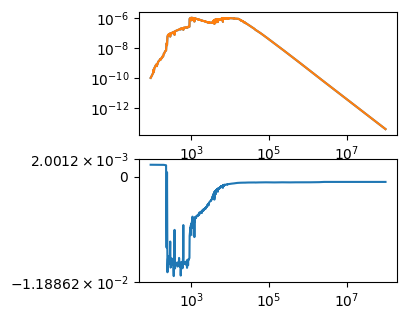

In [260]:
csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'Z':np.log10(Z)}, tuniv = 13.8, tiny_logt = -70, zh_const = True,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": False}, 
                 add_dust = False, add_diffuse_dust = False, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)


spec = run_spectrum_jit(csp, csp.theta_init)

resi = (spec - spec_fsps_nebfree)/spec_fsps_nebfree
fig, axs = plt.subplots(2,1, figsize = (10/3, 3.5))
axs[0].loglog(wave, spec)
axs[0].loglog(wave, spec_fsps_nebfree)
axs[1].semilogx(wave, resi)
axs[1].set_yscale('symlog')

In [261]:
csp_neb = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'Z': Z}, tuniv = 13.8, tiny_logt = -70, zh_const = True,
                 add_neb = True, init_neb_params = {"isoc_type": "mist", "cloudy_dust": False}, 
                 add_dust = False, add_diffuse_dust = False, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)


theta = csp_neb.theta_init.copy()
theta = jnp.array(theta.at[csp_neb.gas_logz_idx].set(sp.params['gas_logz']))
theta = jnp.array(theta.at[csp_neb.gas_logu_idx].set(sp.params['gas_logu']))

spec_neb = run_spectrum_jit(csp_neb, theta)

Dust initialization complete.
Initializing Nebular Emission model...
Get spectrum without dust attenuation, with nebular continuum and lines, and without dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'Z_idx', 'gas_logu_idx', 'gas_logz_idx', 'sfh_idx', 'young_idx'])


NonConcreteBooleanIndexError: Array boolean indices must be concrete; got ShapedArray(bool[5994])

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

In [217]:
res = csp_neb.get_spectrum_nodattn_nodem_neb(theta)

[46.71575  46.61853  46.70655  46.598946 46.627586 46.713356 46.603973
 46.625816 46.707138 46.698013 46.62652  46.694675 46.70954  46.710075
 46.71231  46.713753 46.74212  46.730343 46.746635 46.736824 46.74588
 46.75446  46.775375 46.795925 46.817017 46.843693 46.853546 46.904373
 46.91957  46.96913  47.032417 47.028267 46.955395 46.890266 46.782726
 46.620956 46.52441  46.318108 45.803963 45.65453  45.486217 45.282322
 45.04328  44.805313 44.597168 44.38392  44.17022  43.989063 43.854366
 43.740067 43.516006 43.219933 42.941376 42.860794 42.68126  42.42935
 42.229782 42.04574  41.857384 41.680367 41.49791  41.304993 41.12066
 40.93707  40.750553 40.556873 40.33681  40.128666 39.882774 39.680367
 39.434917 39.23409  39.005157 38.798786 38.617813 38.43405  38.257122
 38.06572  37.908897 37.75504  37.606934 37.44247  37.24913  37.020157
 36.765945 36.504524 36.18732  35.873417 35.499    35.141647 34.75618
 34.342842 33.902737 33.295208 31.803741 30.700851 30.213549 29.788853
 29.488178

In [226]:
w_za = csp_neb.total_weights[:, :, 0]

In [233]:
logqq = csp_neb.logqq

In [234]:
weightq = logqq * w_za

In [237]:
weightq.shape

(12, 107)

In [238]:
jnp.sum(weightq, axis = 0)

Array([ 6.93324375e+04,  1.50713875e+05,  1.69205938e+05,  1.89166188e+05,
        2.12929375e+05,  2.38884875e+05,  2.67954625e+05,  3.00476750e+05,
        3.36521125e+05,  3.78084375e+05,  4.23265500e+05,  4.74824500e+05,
        5.33416000e+05,  5.96852750e+05,  6.70845750e+05,  7.51893500e+05,
        8.41184500e+05,  9.43736000e+05,  1.05378400e+06,  1.18546850e+06,
        1.32657600e+06,  1.48404750e+06,  1.66245700e+06,  1.86057800e+06,
        2.08708000e+06,  2.33626300e+06,  2.61741600e+06,  2.91887800e+06,
        3.25603600e+06,  3.63488600e+06,  4.04273000e+06,  4.51741400e+06,
        5.00567800e+06,  5.40659800e+06,  6.02657200e+06,  6.64259200e+06,
        7.36046000e+06,  8.17224400e+06,  9.11649600e+06,  1.00401200e+07,
        1.09201360e+07,  1.21668320e+07,  1.35925520e+07,  1.50603440e+07,
        1.65886160e+07,  1.82268160e+07,  2.00014160e+07,  2.18252160e+07,
        2.37173280e+07,  2.57215040e+07,  2.76525440e+07,  2.96295520e+07,
        3.15282400e+07,  

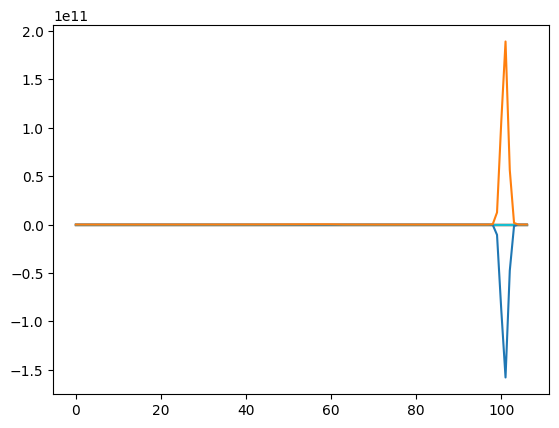

In [236]:
plt.plot(weightq.T)

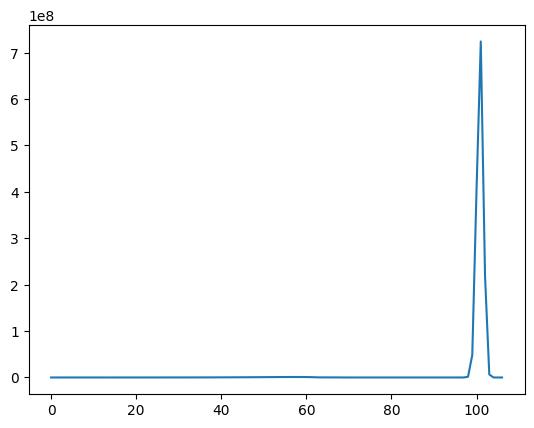

In [232]:
plt.plot(jnp.sum(w_za, axis = 0))

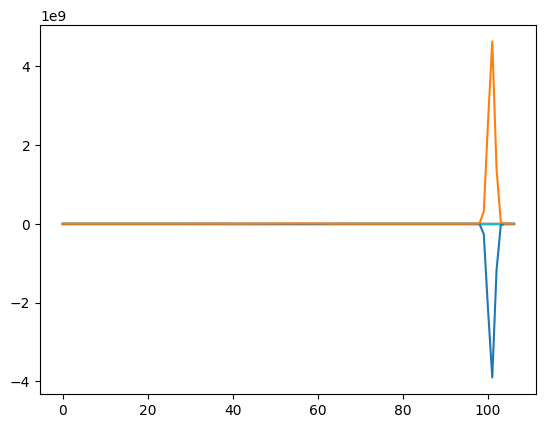

In [229]:
plt.plot(w_za.T)

In [218]:
res =csp_neb.get_spectrum_nodattn_nodem_nebold(theta)

AttributeError: 'CSPBasis' object has no attribute 'get_spectrum_nodattn_nodem_nebold'

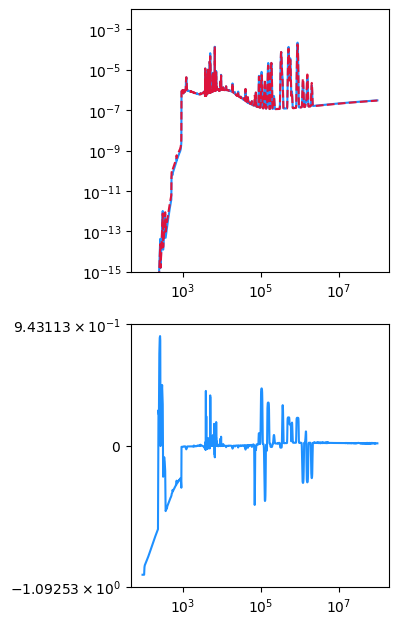

In [219]:
fig, axs = plt.subplots(2, 1, figsize = (10/3,7.5), gridspec_kw={'height_ratios': [3, 3]})

axs[0].loglog(wave, spec_neb, color = 'dodgerblue')
axs[0].loglog(wave, spec_fsps_neb, color = 'crimson', ls = '--')
axs[0].set_ylim(1e-15, 1e-2)

res = (spec_neb - spec_fsps_neb)/spec_fsps_neb

axs[1].semilogx(wave, res, color = 'dodgerblue')
axs[1].set_yscale('symlog')

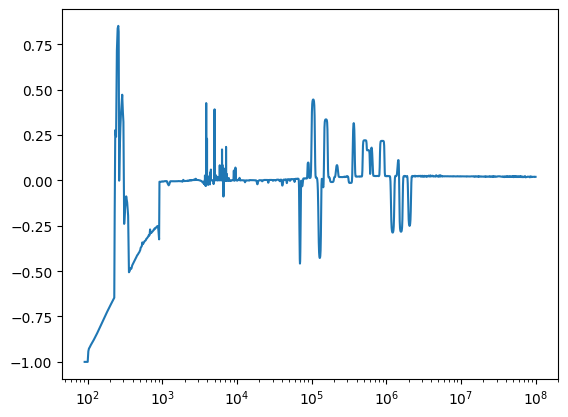

In [146]:
plt.semilogx(wave, res)



In [130]:
sp.params['tage']

13.8